In [118]:
import pandas as pd
import numpy as np
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import NearestNeighbors
import matplotlib.pyplot as plt
import plotly.io as pio
pio.renderers.default = 'notebook'





In [119]:
df = pd.read_csv('../data/masjid-all-2000rows.csv')
df.head()

,Unnamed: 0,no,kabkota,kecamatan,nama_masjid,link,id,tipologi,alamat,LT,...,sdm_jamaah,sdm_imam,sdm_khotib,sdm_muadzin,sdm_remaja,telp,ket,unk,lat,long
0,0,1.0,KOTA ADM. JAKARTA PUSAT,Sawah Besar,Masjid Istiqlal,http://simas.kemenag.go.id/index.php/profil/ma...,01.0.11.03.02.000001,Masjid Negara,"Jl. Taman Wijaya Kusuma Rt.08/02, Kel. Pasar B...",93.200 m2,...,> 200,10,10,-,-,021 3811708,www.istiqlalmosque.com www.mas…,200000.0,-6.1702,106.8311
1,1,1.0,KAB. MAMUJU,Simboro dan Kepulauan,Masjid Baitul Anwar,http://simas.kemenag.go.id/index.php/profil/ma...,01.1.29.02.12.000094,Masjid Raya,KANTOR GUBERNUR SULAWESI BARAT=,2.000 m2,...,> 200,1,1,2,20,NaN,NaN,300.0,-2.6672,118.8525
2,2,2.0,KOTA ADM. JAKARTA BARAT,Cengkareng,"Masjid KH.Hasyim Asy""ari",http://simas.kemenag.go.id/index.php/profil/ma...,01.1.11.04.01.000090,Masjid Raya,Jl.Daan Mogot KM.14.5 Pesakih Rt 3/14 Duri Kos...,24.000 m2,...,> 200,5,40,5,-,NaN,NaN,12500.0,-6.2115,106.8452
3,3,3.0,KOTA MATARAM,Selaprang,Masjid Hubbul Wathan Islamic Centre,http://simas.kemenag.go.id/index.php/profil/ma...,01.1.18.09.05.000051,Masjid Raya,Jln. Udayana No. 1 Kota Mataram,10.000 m2,...,150 - 200,4,10,-,-,NaN,NaN,1000.0,-8.5890,116.1304
4,4,4.0,KOTA SORONG,Sorong,Masjid Al-Akbar,http://simas.kemenag.go.id/index.php/profil/ma...,01.1.33.11.01.000001,Masjid Raya,Jl. Ahmad Yani No 40 Kota Sorong Papua Barat,1.400 m2,...,> 200,3,8,3,-,NaN,NaN,1000.0,-0.8820,131.2820


In [120]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 23 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Unnamed: 0     2000 non-null   int64  
 1   no             2000 non-null   float64
 2   kabkota        2000 non-null   object 
 3   kecamatan      2000 non-null   object 
 4   nama_masjid    2000 non-null   object 
 5   link           2000 non-null   object 
 6   id             2000 non-null   object 
 7   tipologi       2000 non-null   object 
 8   alamat         2000 non-null   object 
 9   LT             2000 non-null   object 
 10  status         2000 non-null   object 
 11  LB             2000 non-null   object 
 12  tahun_berdiri  2000 non-null   float64
 13  sdm_jamaah     2000 non-null   object 
 14  sdm_imam       2000 non-null   object 
 15  sdm_khotib     2000 non-null   object 
 16  sdm_muadzin    2000 non-null   object 
 17  sdm_remaja     2000 non-null   object 
 18  telp    

In [121]:
df.describe()


,Unnamed: 0,no,tahun_berdiri,unk,lat,long
count,2000.000000,2000.000000,2000.000000,2.000000e+03,2000.000000,2000.000000
mean,999.500000,653.279000,1950.857500,1.767062e+03,-3.915797,113.624203
std,577.494589,472.846342,273.214301,2.837759e+04,22.714830,30.428879
min,0.000000,1.000000,0.000000,0.000000e+00,-1000.000000,-87.555900
25%,499.750000,233.750000,1955.000000,2.000000e+02,-6.480775,107.603500
50%,999.500000,565.500000,1980.000000,4.000000e+02,-1.801500,116.147500
75%,1499.250000,1065.250000,1995.000000,1.000000e+03,-1.801500,116.147500
max,1999.000000,1565.000000,9999.000000,1.250000e+06,53.180100,1000.000000


In [122]:
df.isnull().sum()


Unnamed: 0          0
no                  0
kabkota             0
kecamatan           0
nama_masjid         0
link                0
id                  0
tipologi            0
alamat              0
LT                  0
status              0
LB                  0
tahun_berdiri       0
sdm_jamaah          0
sdm_imam            0
sdm_khotib          0
sdm_muadzin         0
sdm_remaja          0
telp             1018
ket              1909
unk                 0
lat                 0
long                0
dtype: int64

In [123]:
df.columns

Index(['Unnamed: 0', 'no', 'kabkota', 'kecamatan', 'nama_masjid', 'link', 'id',
       'tipologi', 'alamat', 'LT', 'status', 'LB', 'tahun_berdiri',
       'sdm_jamaah', 'sdm_imam', 'sdm_khotib', 'sdm_muadzin', 'sdm_remaja',
       'telp', 'ket', 'unk', 'lat', 'long'],
      dtype='object')

In [124]:
df = df.drop(columns=['ket', 'telp'])



In [125]:
df.columns

Index(['Unnamed: 0', 'no', 'kabkota', 'kecamatan', 'nama_masjid', 'link', 'id',
       'tipologi', 'alamat', 'LT', 'status', 'LB', 'tahun_berdiri',
       'sdm_jamaah', 'sdm_imam', 'sdm_khotib', 'sdm_muadzin', 'sdm_remaja',
       'unk', 'lat', 'long'],
      dtype='object')

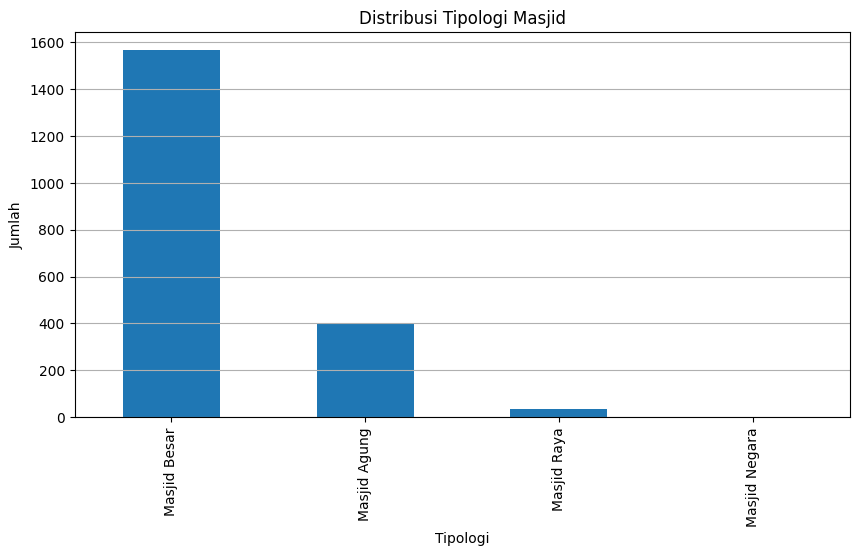

In [126]:
plt.figure(figsize=(10,5))
df['tipologi'].value_counts().plot(kind='bar')
plt.title('Distribusi Tipologi Masjid')
plt.xlabel('Tipologi')
plt.ylabel('Jumlah')
plt.grid(axis='y')
plt.show()


In [127]:
df['provinsi'] = df['kabkota'].str.split().str[-1]
df['provinsi'].value_counts().head(10)


provinsi
TIMUR          122
BARAT           80
SELATAN         77
UTARA           73
TENGAH          47
SEMARANG        39
TASIKMALAYA     31
LAMPUNG         31
GARUT           29
ILIR            29
Name: count, dtype: int64

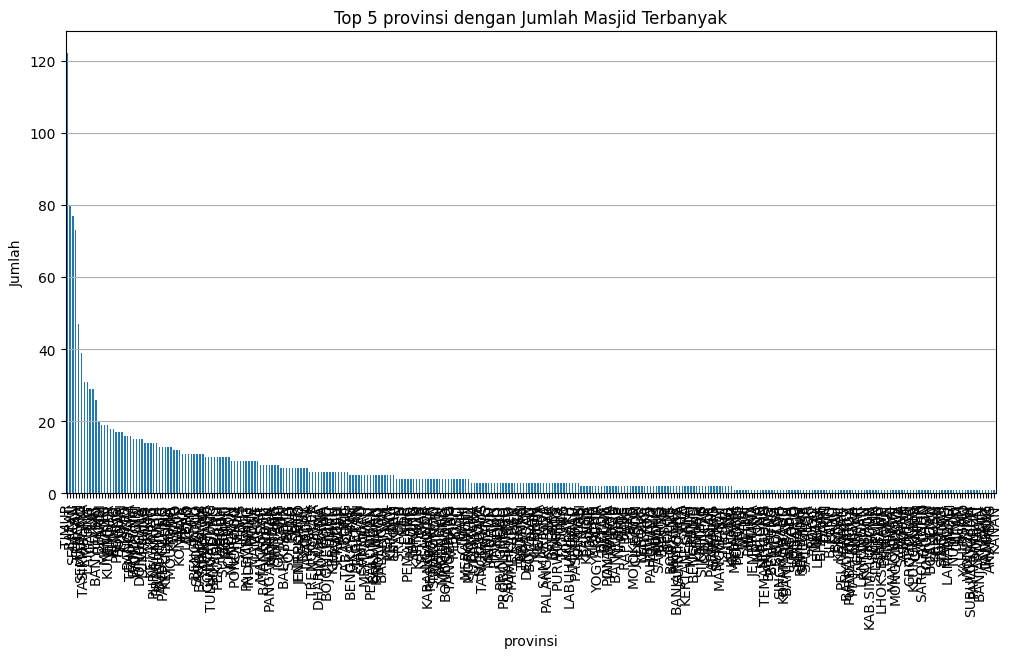

In [128]:
plt.figure(figsize=(12,6))
df['provinsi'].value_counts().plot(kind='bar')
plt.title('Top 5 provinsi dengan Jumlah Masjid Terbanyak')
plt.ylabel('Jumlah')
plt.grid(axis='y')
plt.show()


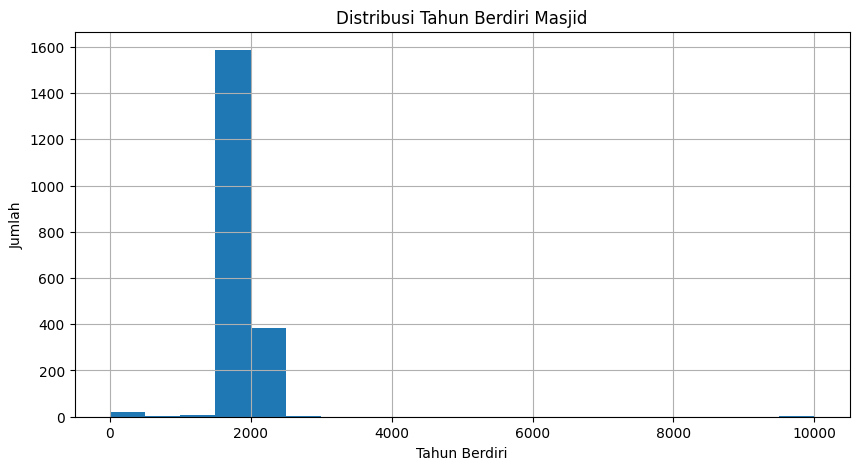

In [129]:
plt.figure(figsize=(10,5))
df['tahun_berdiri'] = pd.to_numeric(df['tahun_berdiri'], errors='coerce')
df['tahun_berdiri'].dropna().plot(kind='hist', bins=20)
plt.title('Distribusi Tahun Berdiri Masjid')
plt.xlabel('Tahun Berdiri')
plt.ylabel('Jumlah')
plt.grid()
plt.show()


In [130]:
def clean_area(x):
    if pd.isna(x):
        return np.nan
    x = str(x).replace('.', '')       # hapus titik pemisah ribuan
    x = x.replace('m2', '')           # hapus satuan m2
    x = x.replace('m', '')            # jaga-jaga
    x = x.strip()
    return pd.to_numeric(x, errors='coerce')

df['LT_clean'] = df['LT'].apply(clean_area)
df['LB_clean'] = df['LB'].apply(clean_area)


In [131]:
df[['LT', 'LT_clean', 'LB', 'LB_clean']].head()



,LT,LT_clean,LB,LB_clean
0,93.200 m2,93200.0,24.200 m2,24200.0
1,2.000 m2,2000.0,1.500 m2,1500.0
2,24.000 m2,24000.0,1.698.543 m2,1698543.0
3,10.000 m2,10000.0,1.500 m2,1500.0
4,1.400 m2,1400.0,1.000 m2,1000.0


In [132]:
df[['LT_clean', 'LB_clean']].describe()


,LT_clean,LB_clean
count,1.834000e+03,1.833000e+03
mean,3.172383e+04,2.151899e+03
std,6.796486e+05,4.006952e+04
min,1.500000e+01,1.000000e+01
25%,6.000000e+02,2.400000e+02
50%,1.356500e+03,4.180000e+02
75%,3.000000e+03,9.000000e+02
max,2.000000e+07,1.698543e+06


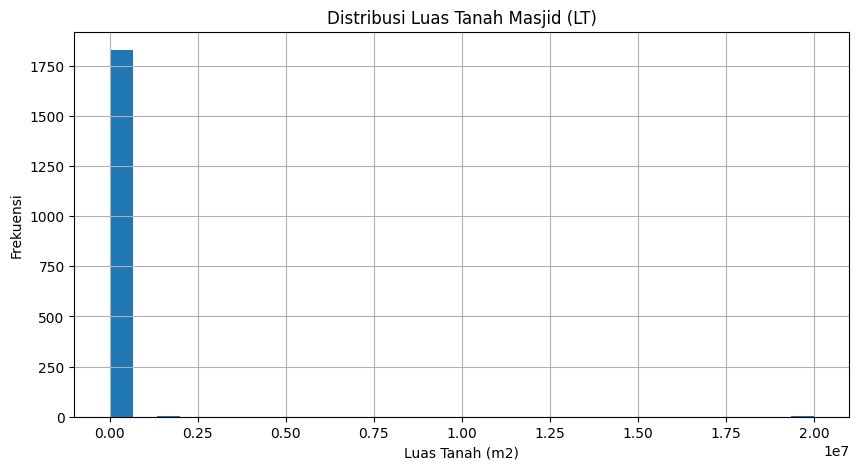

In [133]:
plt.figure(figsize=(10,5))
df['LT_clean'].plot(kind='hist', bins=30)
plt.title('Distribusi Luas Tanah Masjid (LT)')
plt.xlabel('Luas Tanah (m2)')
plt.ylabel('Frekuensi')
plt.grid()
plt.show()


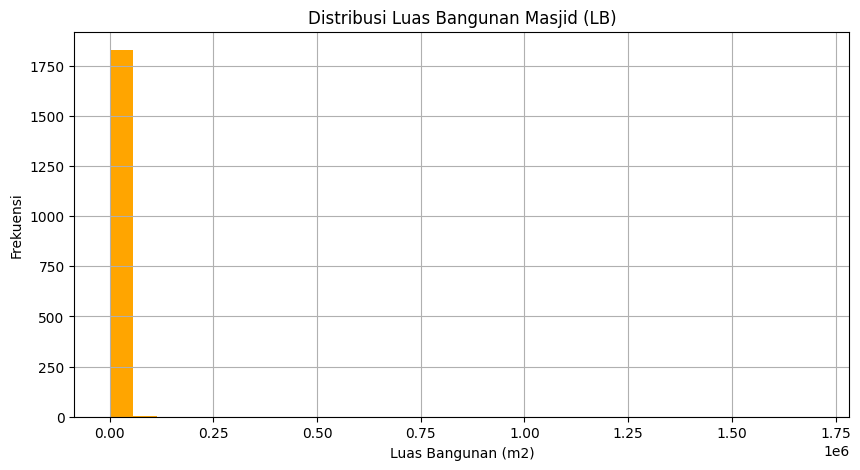

In [134]:
plt.figure(figsize=(10,5))
df['LB_clean'].plot(kind='hist', bins=30, color='orange')
plt.title('Distribusi Luas Bangunan Masjid (LB)')
plt.xlabel('Luas Bangunan (m2)')
plt.ylabel('Frekuensi')
plt.grid()
plt.show()


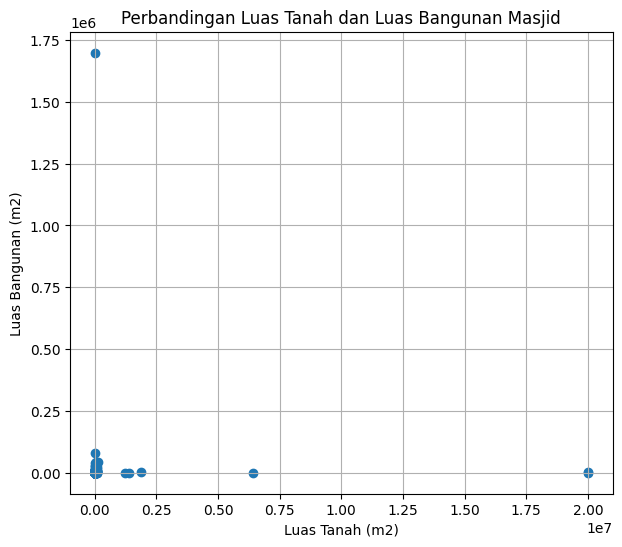

In [135]:
plt.figure(figsize=(7,6))
plt.scatter(df['LT_clean'], df['LB_clean'])
plt.xlabel('Luas Tanah (m2)')
plt.ylabel('Luas Bangunan (m2)')
plt.title('Perbandingan Luas Tanah dan Luas Bangunan Masjid')
plt.grid()
plt.show()


In [136]:
X = df[['lat', 'long']].values


In [137]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


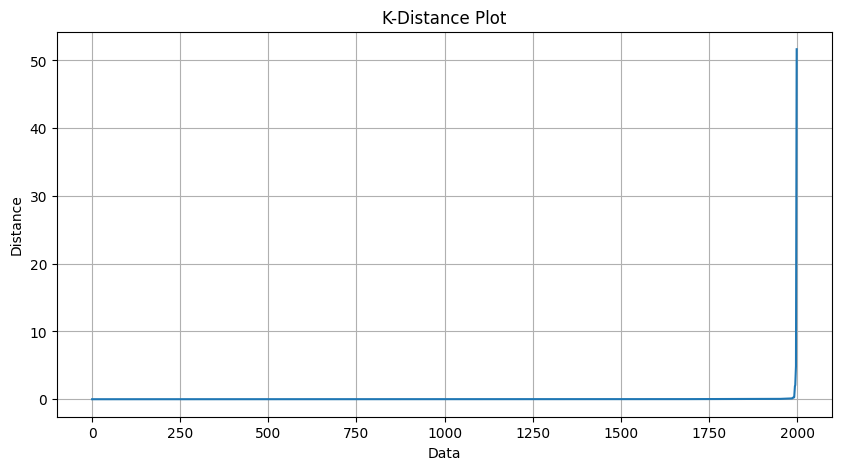

In [138]:
from sklearn.neighbors import NearestNeighbors
import numpy as np
import matplotlib.pyplot as plt

neighbors = 5
nbrs = NearestNeighbors(n_neighbors=neighbors).fit(X_scaled)
distances, indices = nbrs.kneighbors(X_scaled)

distances = np.sort(distances[:, -1])

plt.figure(figsize=(10,5))
plt.plot(distances)
plt.title("K-Distance Plot")
plt.xlabel("Data")
plt.ylabel("Distance")
plt.grid(True)
plt.show()


In [139]:
from sklearn.cluster import DBSCAN

db = DBSCAN(eps=0.35, min_samples=10)
clusters = db.fit_predict(X_scaled)

df['Cluster'] = clusters.astype(str)


In [140]:
df['Cluster'].value_counts()


Cluster
0     1983
1       10
-1       7
Name: count, dtype: int64

In [147]:
import plotly.express as px

df['Cluster'] = df['Cluster'].astype(str)

fig = px.scatter_mapbox(
    df,
    lat='lat',
    lon='long',
    color='Cluster',               # <-- warna beda untuk tiap cluster
    hover_name='nama_masjid',
    hover_data=['kabkota', 'kecamatan', 'tipologi'],
    zoom=4,
    height=650,
    title='Peta Klaster Masjid Berdasarkan DBSCAN'
)

fig.update_layout(
    mapbox_style='open-street-map',   # tidak butuh token
    legend_title_text='Cluster',
)

fig.show()


C:\Users\MyBook Hype AMD\AppData\Local\Temp\ipykernel_2480\711238870.py:5: DeprecationWarning:

*scatter_mapbox* is deprecated! Use *scatter_map* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/

